In [4]:
import pandas as pd

# Load CSV (same folder as notebook)
data = pd.read_csv('sales_data.csv', parse_dates=['Date'])

# Show first 5 rows
data.head()



,Order ID,Product,Category,Region,Sales,Quantity,Date
0,1001,Laptop,Tech,North,1200,2,2026-01-05
1,1002,Chair,Furniture,South,150,5,2026-01-06
2,1003,Mouse,Tech,East,25,10,2026-01-07
3,1004,Desk,Furniture,West,300,3,2026-01-08
4,1005,Monitor,Tech,North,250,2,2026-01-08


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Order ID  100 non-null    int64         
 1   Product   100 non-null    str           
 2   Category  100 non-null    str           
 3   Region    100 non-null    str           
 4   Sales     100 non-null    int64         
 5   Quantity  100 non-null    int64         
 6   Date      100 non-null    datetime64[us]
dtypes: datetime64[us](1), int64(3), str(3)
memory usage: 5.6 KB


In [6]:
data.describe()

,Order ID,Sales,Quantity,Date
count,100.000000,100.000000,100.000000,100
mean,1050.500000,241.350000,4.420000,2026-02-21 15:07:12
min,1001.000000,10.000000,1.000000,2026-01-05 00:00:00
25%,1025.750000,44.250000,1.000000,2026-01-27 18:00:00
50%,1050.500000,162.500000,2.000000,2026-02-21 12:00:00
75%,1075.250000,310.000000,5.000000,2026-03-18 06:00:00
max,1100.000000,1250.000000,25.000000,2026-04-12 00:00:00
std,29.011492,290.589939,5.308998,NaN


In [7]:
data.isnull().sum()


Order ID    0
Product     0
Category    0
Region      0
Sales       0
Quantity    0
Date        0
dtype: int64

<Axes: title={'center': 'Monthly Sales'}, xlabel='Month'>

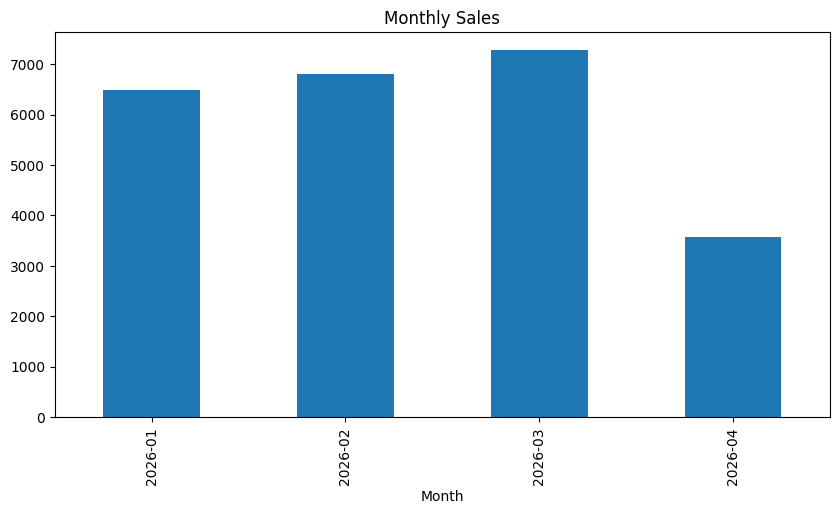

In [8]:
# Convert Date column to month
data['Month'] = data['Date'].dt.to_period('M')

# Sum sales by month
monthly_sales = data.groupby('Month')['Sales'].sum()

# Plot bar chart
monthly_sales.plot(kind='bar', figsize=(10,5), title='Monthly Sales')




<Axes: title={'center': 'Top 10 Products'}, ylabel='Product'>

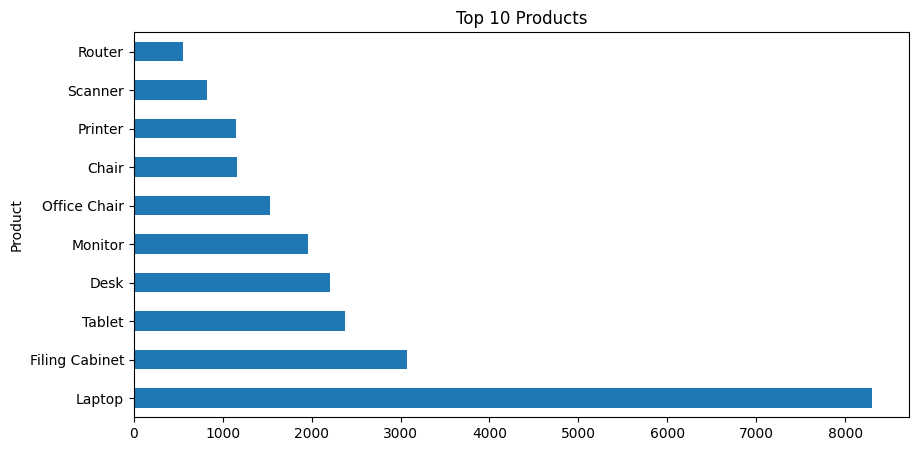

In [10]:
top_products = data.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh', figsize=(10,5), title='Top 10 Products')




<Axes: title={'center': 'Sales by Region'}>

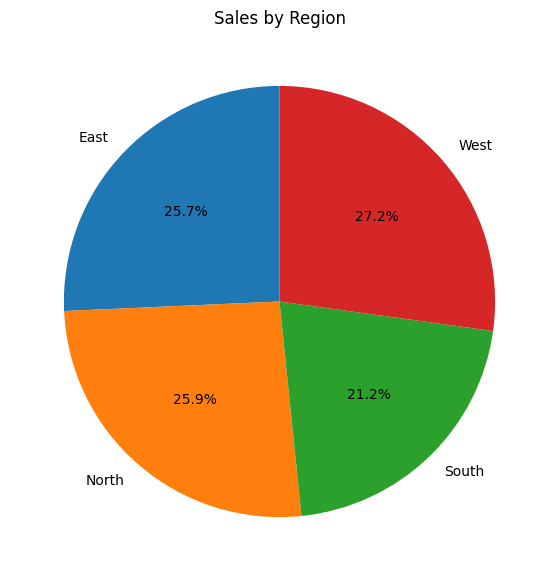

In [11]:
region_sales = data.groupby('Region')['Sales'].sum()

region_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(7,7), title='Sales by Region')




First 5 rows:


,Order ID,Product,Category,Region,Sales,Quantity,Date
0,1001,Laptop,Tech,North,1200,2,2026-01-05
1,1002,Chair,Furniture,South,150,5,2026-01-06
2,1003,Mouse,Tech,East,25,10,2026-01-07
3,1004,Desk,Furniture,West,300,3,2026-01-08
4,1005,Monitor,Tech,North,250,2,2026-01-08



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Order ID  100 non-null    int64         
 1   Product   100 non-null    str           
 2   Category  100 non-null    str           
 3   Region    100 non-null    str           
 4   Sales     100 non-null    int64         
 5   Quantity  100 non-null    int64         
 6   Date      100 non-null    datetime64[us]
dtypes: datetime64[us](1), int64(3), str(3)
memory usage: 5.6 KB

Summary Statistics:


,Order ID,Sales,Quantity,Date
count,100.000000,100.000000,100.000000,100
mean,1050.500000,241.350000,4.420000,2026-02-21 15:07:12
min,1001.000000,10.000000,1.000000,2026-01-05 00:00:00
25%,1025.750000,44.250000,1.000000,2026-01-27 18:00:00
50%,1050.500000,162.500000,2.000000,2026-02-21 12:00:00
75%,1075.250000,310.000000,5.000000,2026-03-18 06:00:00
max,1100.000000,1250.000000,25.000000,2026-04-12 00:00:00
std,29.011492,290.589939,5.308998,NaN



Missing Values per Column:


Order ID    0
Product     0
Category    0
Region      0
Sales       0
Quantity    0
Date        0
dtype: int64

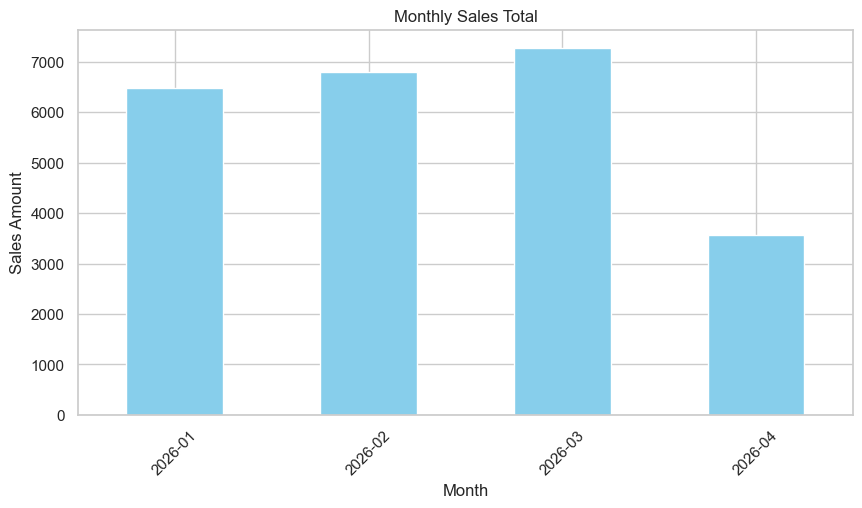

C:\Users\Nabeel\AppData\Local\Temp\ipykernel_19684\2071339819.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')


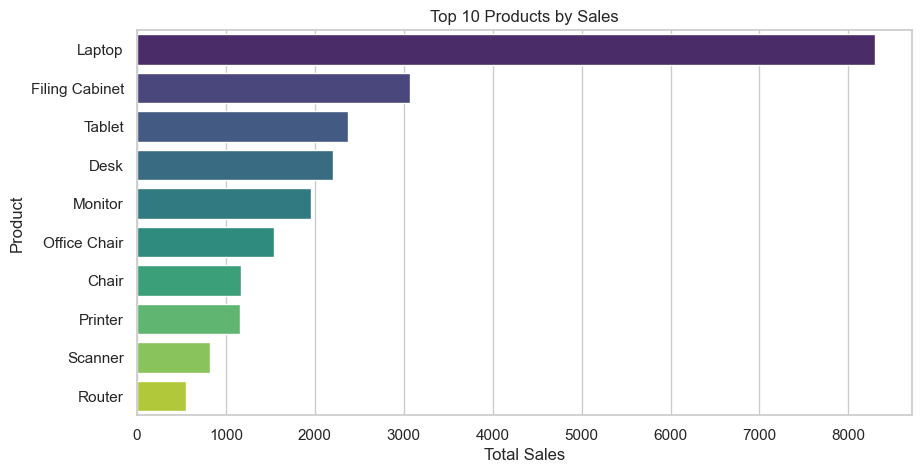

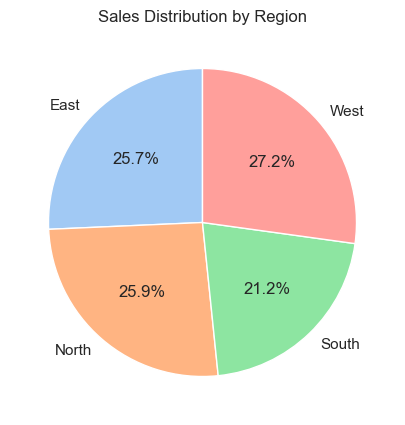

Next 3-Month Forecast:


,Month_Num,Forecasted_Sales
0,4,3965.5
1,5,3138.2
2,6,2310.9


✅ Summary Excel file saved as 'sales_summary.xlsx'


In [16]:
# Step 3: Explore, Visualize & Forecast Sales Data

# 1️⃣ Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

# Optional: make charts prettier
sns.set(style='whitegrid')
%matplotlib inline

# ------------------------------------------------------
# 2️⃣ Load sales data (same folder as notebook)
data = pd.read_csv('sales_data.csv', encoding='utf-8', encoding_errors='replace', parse_dates=['Date'])

# Quick check
print("First 5 rows:")
display(data.head())

print("\nDataset Info:")
data.info()

print("\nSummary Statistics:")
display(data.describe())

print("\nMissing Values per Column:")
display(data.isnull().sum())

# ------------------------------------------------------
# 3️⃣ Create basic visualizations

# Monthly sales total
data['Month'] = data['Date'].dt.to_period('M')
monthly_sales = data.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='bar', color='skyblue')
plt.title('Monthly Sales Total')
plt.ylabel('Sales Amount')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.show()

# Top 10 products by total sales
top_products = data.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.show()

# Sales by Region
region_sales = data.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Sales Distribution by Region')
plt.ylabel('')
plt.show()

# ------------------------------------------------------
# 4️⃣ Simple 3-Month Sales Forecast using Linear Regression

# Prepare data
monthly_sales_reset = monthly_sales.reset_index()
monthly_sales_reset['Month_Num'] = np.arange(len(monthly_sales_reset))

X = monthly_sales_reset[['Month_Num']]  # DataFrame
y = monthly_sales_reset['Sales']

# Train Linear Regression
model = LinearRegression()
model.fit(X, y)

# Forecast next 3 months (use DataFrame to avoid sklearn warnings)
future_months_df = pd.DataFrame({'Month_Num': [len(X), len(X)+1, len(X)+2]})
forecast = model.predict(future_months_df)

forecast_df = pd.DataFrame({
    'Month_Num': future_months_df['Month_Num'],
    'Forecasted_Sales': forecast
})
print("Next 3-Month Forecast:")
display(forecast_df)

# ------------------------------------------------------
# 5️⃣ Save Summary & Forecast to Excel
with pd.ExcelWriter('sales_summary.xlsx') as writer:
    # Original data
    data.to_excel(writer, sheet_name='Sales_Data', index=False)
    
    # Monthly sales summary
    monthly_sales_reset[['Month','Sales']].to_excel(writer, sheet_name='Monthly_Sales', index=False)
    
    # Forecast
    forecast_df.to_excel(writer, sheet_name='Forecast', index=False)
    
    # Top products
    top_products.reset_index().rename(columns={'Product':'Product','Sales':'Total_Sales'}).to_excel(writer, sheet_name='Top_Products', index=False)
    
    # Sales by region
    region_sales.reset_index().rename(columns={'Region':'Region','Sales':'Total_Sales'}).to_excel(writer, sheet_name='Region_Sales', index=False)

print("✅ Summary Excel file saved as 'sales_summary.xlsx'")